In [1]:
# Install required libraries if you haven't already
# !pip install tensorflow pandas numpy sklearn matplotlib seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [2]:
# Load dataset
df = pd.read_csv('netflix_titles.csv')

# Extract primary genre from 'listed_in' column
df['Genre'] = df['listed_in'].apply(lambda x: x.split(',')[0].strip())

# Filter for major film categories to ensure balanced and reliable training context
target_genres = ['Dramas', 'Comedies', 'Action & Adventure', 'Horror Movies', 'Documentaries']
data = df[df['Genre'].isin(target_genres)][['Genre', 'description']].dropna().reset_index(drop=True)

print(f"Dataset summary:\n{data['Genre'].value_counts()}")

Dataset summary:
Genre
Dramas                1600
Comedies              1210
Action & Adventure     859
Documentaries          829
Horror Movies          275
Name: count, dtype: int64


In [3]:
# Parameters
vocab_size = 10000
max_len = 30
embedding_dim = 50

# Tokenize descriptions
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(data['description'])
sequences = tokenizer.texts_to_sequences(data['description'])
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Encode genres
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(data['Genre'])
num_classes = len(np.unique(y_encoded))
y = to_categorical(y_encoded, num_classes=num_classes)

# Split train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# Functional Model Setup
inputs = Input(shape=(max_len,))
embedding_layer = Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim)(inputs)

# Explicitly calling activation='tanh' and recurrent_activation='sigmoid' for the LSTM components
lstm_1 = LSTM(64, activation='tanh', recurrent_activation='sigmoid', return_sequences=True)(embedding_layer)
dropout_1 = Dropout(0.2)(lstm_1)

lstm_2 = LSTM(32, activation='tanh', recurrent_activation='sigmoid', return_sequences=False)(dropout_1)
dropout_2 = Dropout(0.2)(lstm_2)

# Dense final layer with softmax for multiclass classification
outputs = Dense(num_classes, activation='softmax')(dropout_2)

model = Model(inputs=inputs, outputs=outputs)
model.compile(loss='categorical_transform' if tf.__version__ < '2.0' else 'categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 50)         │       500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,071 (2.07 MB)

 Trainable params: 542,071 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Reduce epochs for quick demonstration, update validation strategy
history = model.fit(
    X_train, y_train,
    epochs=4,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/4
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6865 - loss: 0.7799 - val_accuracy: 0.5257 - val_loss: 1.1451
Epoch 2/4
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.8274 - loss: 0.4945 - val_accuracy: 0.5246 - val_loss: 1.3307
Epoch 3/4
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8908 - loss: 0.3306 - val_accuracy: 0.5330 - val_loss: 1.5247
Epoch 4/4
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9379 - loss: 0.2199 - val_accuracy: 0.5560 - val_loss: 1.6804


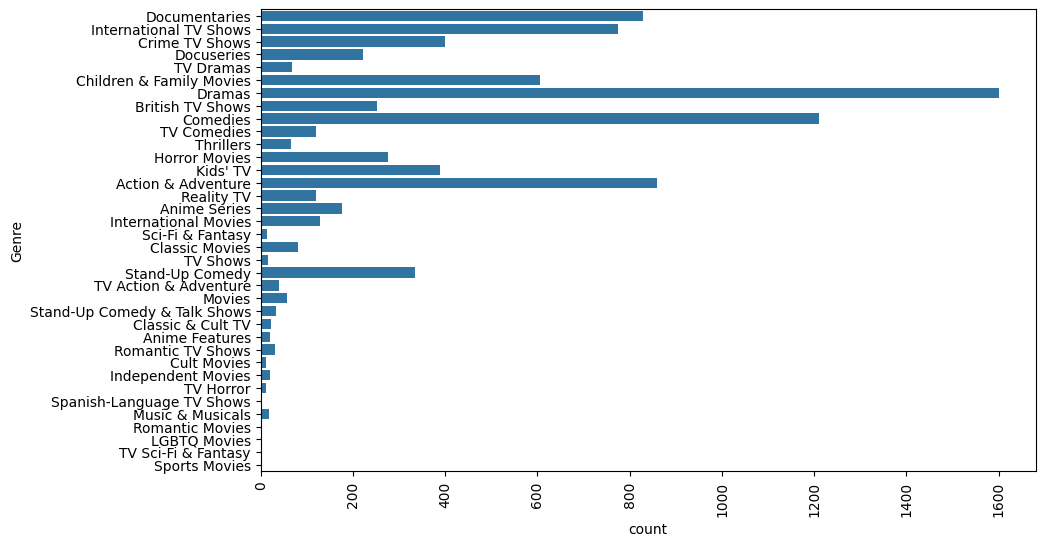

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(df['Genre'])
plt.xticks(rotation=90)
plt.show()

In [11]:
data = df[df.Genre.isin(target_genres)][['Genre','description']]
data

,Genre,description
0,Documentaries,"As her father nears the end of his life, filmm..."
7,Dramas,"On a photo shoot in Ghana, an American model s..."
9,Comedies,A woman adjusting to life after a loss contend...
12,Dramas,After most of her family is murdered in a terr...
16,Documentaries,Declassified documents reveal the post-WWII li...
...,...,...
8798,Comedies,A philandering small-town mechanic's political...
8799,Dramas,A change in the leadership of a political part...
8801,Dramas,Recovering alcoholic Talal wakes up inside a s...
8804,Comedies,Looking to survive in a world taken over by zo...


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step

=== Classification Report ===
                    precision    recall  f1-score   support

Action & Adventure       0.53      0.45      0.49       172
          Comedies       0.52      0.49      0.51       242
     Documentaries       0.76      0.73      0.74       166
            Dramas       0.52      0.63      0.57       320
     Horror Movies       0.32      0.20      0.25        55

          accuracy                           0.56       955
         macro avg       0.53      0.50      0.51       955
      weighted avg       0.55      0.56      0.55       955



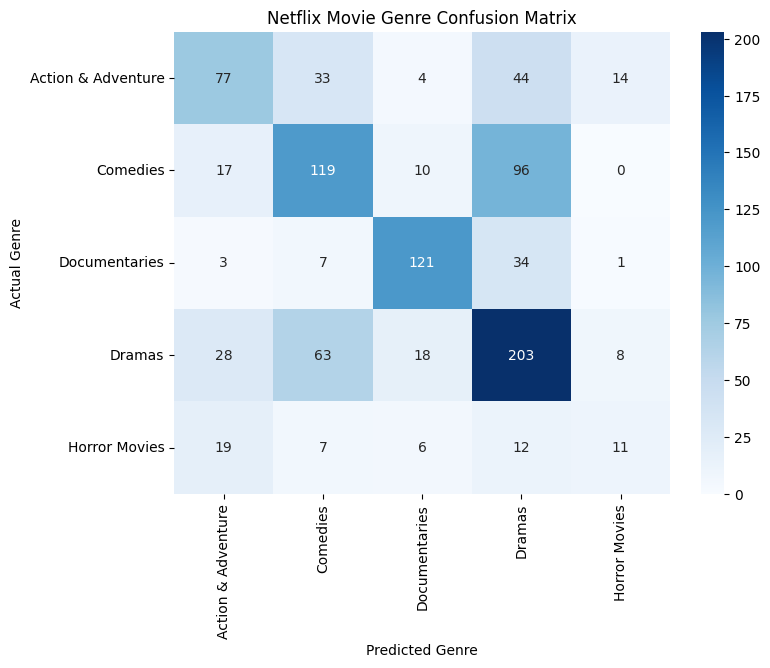

In [7]:
# Extract predictions
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Generate Corrected Classification Report and Confusion Matrix
print("\n=== Classification Report ===")
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# Visualize confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
plt.title('Netflix Movie Genre Confusion Matrix')
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.show()

In [8]:
def predict_movie_genre(movie_description):
    # Process text input the same way as training sequences
    test_seq = tokenizer.texts_to_sequences([movie_description])
    test_padded = pad_sequences(test_seq, maxlen=max_len, padding='post', truncating='post')

    # Predict probabilities
    pred_probabilities = model.predict(test_padded)
    predicted_class_idx = np.argmax(pred_probabilities, axis=1)[0]

    # Map back to string name
    predicted_genre = label_encoder.inverse_transform([predicted_class_idx])[0]
    confidence = pred_probabilities[0][predicted_class_idx] * 100

    print(f"\nDescription: \"{movie_description}\"")
    print(f"Predicted Genre: {predicted_genre} ({confidence:.2f}% confidence)")

# Example Trial Run
sample_summary = "A psychopathic serial killer tracks down unsuspecting college students in a remote cabin during a dark storm."
predict_movie_genre(sample_summary)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

Description: "A psychopathic serial killer tracks down unsuspecting college students in a remote cabin during a dark storm."
Predicted Genre: Action & Adventure (89.80% confidence)
